# 深度学习课程设计报告

## 一、封面

- 课程名称：深度学习  
- 设计题目：基于两阶段级联 U-Net 的心脏核磁图像分割  
- 姓    名：  曹宇扬
- 学    号：  20234080103
- 班    级：  本23数据01班
- 指导教师：  丁平尖
- 提交日期：  

## 二、摘要

本项目面向心脏医学图像分割任务，设计并实现了一种基于解剖先验引导的两阶段级联分割方法。项目使用 ACDC 数据集训练第一阶段 U-Net 定位器，用于预测左心室与心肌区域的粗定位 mask；随后使用 MyoPS 2020 数据集训练第二阶段 U-Net 分割器，将 LGE、T2、bSSFP 三个配准序列与第一阶段生成的定位 mask 进行融合，实现背景、正常心肌、水肿和疤痕的四分类分割。

为验证解剖先验的有效性，项目同时实现了一个仅使用三模态图像输入的标准 U-Net 作为 Baseline，并与加入定位 mask 的 Cascade 模型进行对比。实验中采用 Dice 系数和 HD95 作为主要评价指标，并通过可视化结果分析模型在不同类别上的分割表现。实验结果显示，改进后的训练策略显著提升了模型对水肿和疤痕等小目标病灶的识别能力；其中 Cascade 模型在疤痕 Dice 上优于 Baseline，说明解剖定位先验对部分病灶区域具有积极作用。但水肿类别仍存在边界模糊和分割不稳定的问题，后续仍需进一步优化先验融合方式和边界约束策略。

## 三、问题定义与需求分析

### 3.1 项目背景与意义

心脏磁共振成像是心肌疾病诊断和评估的重要工具。通过对心肌、心室以及水肿、疤痕等病灶区域进行准确分割，可以辅助医生评估心肌损伤范围、病灶形态和疾病严重程度。传统人工标注方式耗时较长，且容易受到医生经验和主观判断影响，因此利用深度学习方法实现自动医学图像分割具有较高的实际应用价值。

在心脏医学图像分割中，正常心肌、水肿和疤痕等区域通常存在边界模糊、形态变化大、类别不平衡等问题。尤其是水肿和疤痕区域，像素占比较小，直接使用普通分割网络容易出现漏分和误分。因此，本项目尝试引入心脏解剖结构先验，通过“先定位、后分割”的两阶段级联策略，提高模型对目标区域的关注能力。

### 3.2 问题描述

本项目属于医学图像语义分割任务。

第一阶段任务为二分类定位任务：

- 输入：ACDC 数据集中的单通道 bSSFP 图像；
- 输出：左心室与心肌区域的二值定位 mask；
- 目标：学习心脏解剖区域的大致空间范围。

第二阶段任务为四分类分割任务：

- 输入：MyoPS 2020 数据集中的 LGE、T2、bSSFP 三模态图像，以及第一阶段生成的定位 mask；
- 输出：背景、正常心肌、水肿、疤痕四类分割结果；
- 目标：完成多模态心脏核磁图像中的心肌结构和病灶区域分割。

本项目主要评价指标包括：

- Dice 系数：衡量预测区域与真实区域的重叠程度；
- HD95：衡量预测边界与真实边界之间的距离误差；
- 分类别 Dice：分别评估背景、正常心肌、水肿和疤痕的分割效果。

## 四、数据集说明与预处理

### 4.1 数据来源与规模

本项目使用两个公开医学图像数据集：

1. **ACDC 数据集**

   ACDC 数据集用于训练第一阶段定位器。该阶段主要使用 bSSFP 序列图像，并将左心室和心肌区域合并为前景，构建二分类定位任务。

2. **MyoPS 2020 数据集**

   MyoPS 2020 数据集用于训练第二阶段精细分割器。该数据集包含 LGE、T2、bSSFP 三个已经配准好的序列，项目将三种模态直接堆叠为三通道输入，并结合第一阶段生成的定位 mask 形成四通道输入。

MyoPS 四分类标签定义如下：

| 类别编号 | 类别名称 |
|---:|---|
| 0 | 背景 |
| 1 | 正常心肌 |
| 2 | 水肿 |
| 3 | 疤痕 |

### 4.2 数据可视化与分析

MyoPS 数据集中，背景和正常心肌区域相对较多，而水肿和疤痕属于小目标类别，像素占比较低。类别不平衡是该任务的主要难点之一。为了观察模型效果，本项目在推理阶段生成四联图，包括原始 bSSFP 图像、真实标签、Baseline 预测结果和 Cascade 预测结果。

颜色约定如下：

| 类别 | 颜色 |
|---|---|
| 背景 | 黑色 |
| 正常心肌 | 蓝色 |
| 水肿 | 黄色 |
| 疤痕 | 红色 |

### 4.3 预处理流程

本项目采用以下预处理与增强方法：

1. 将所有图像统一 resize 到 `256×256`；
2. 对图像执行 Z-score 归一化；
3. 标签图使用最近邻插值，避免类别值被破坏；
4. MyoPS 三个序列已经配准，直接堆叠为三通道输入；
5. 训练阶段使用随机旋转、水平翻转和随机缩放进行数据增强；
6. 数据集划分为训练集、验证集和测试集；
7. 对包含水肿和疤痕的切片进行加权采样，缓解小目标类别不平衡问题。

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Markdown

PROJECT_ROOT = Path(r"D:\a")
ACDC_ROOT = Path(r"C:\Users\C\Desktop\data\ACDC")
MYOPS_ROOT = Path(r"C:\Users\C\Desktop\data\MyoPS 2020 Dataset")

RESULT_DIR = PROJECT_ROOT / "results"
FIGURE_DIR = RESULT_DIR / "figures"
CURVE_DIR = RESULT_DIR / "curves"
TABLE_DIR = RESULT_DIR / "tables"

display(Markdown("## 数据路径检查"))

paths = {
    "项目根目录": PROJECT_ROOT,
    "ACDC 数据集": ACDC_ROOT,
    "MyoPS 数据集": MYOPS_ROOT,
    "结果目录": RESULT_DIR,
    "可视化目录": FIGURE_DIR,
    "曲线目录": CURVE_DIR,
    "指标表格目录": TABLE_DIR,
}

for name, path in paths.items():
    print(f"{name}: {path} -> {'存在' if path.exists() else '不存在'}")

## 数据路径检查

项目根目录: D:\a -> 存在
ACDC 数据集: C:\Users\C\Desktop\data\ACDC -> 存在
MyoPS 数据集: C:\Users\C\Desktop\data\MyoPS 2020 Dataset -> 存在
结果目录: D:\a\results -> 存在
可视化目录: D:\a\results\figures -> 存在
曲线目录: D:\a\results\curves -> 存在
指标表格目录: D:\a\results\tables -> 存在


## 五、模型设计与选择

### 5.1 基准模型（Baseline）

本项目设置标准 U-Net 作为基准模型。Baseline 模型仅使用 MyoPS 数据集中的 LGE、T2、bSSFP 三个模态作为输入，不引入额外的解剖先验信息，直接输出背景、正常心肌、水肿和疤痕四类分割结果。

Baseline 的作用是作为对照组，用于判断加入定位 mask 后的 Cascade 模型是否能够提升病灶分割性能。

Baseline 输入输出定义如下：

- 输入：三通道图像，分别为 LGE、T2、bSSFP；
- 输出：四分类分割图；
- 网络结构：U-Net；
- 编码器：ResNet34；
- 评价重点：水肿和疤痕等病灶类别的 Dice 与 HD95。

### 5.2 最终模型架构

最终模型采用两阶段级联结构，由 U-Net-Locator 和 U-Net-Segmentor 两部分组成。

第一阶段为 U-Net-Locator，用于学习心脏解剖区域的粗定位。该阶段使用 ACDC 数据集进行训练，输入为单通道 bSSFP 图像，输出为左心室和心肌区域的二值 mask。该 mask 表示心肌相关区域的大致位置，可作为第二阶段的空间先验。

第二阶段为 U-Net-Segmentor，用于完成 MyoPS 数据集上的精细分割。该阶段输入包括 LGE、T2、bSSFP 三个模态，以及第一阶段生成的定位 mask，共四个通道。输出为背景、正常心肌、水肿和疤痕四类分割结果。

整体流程如下：

```text
ACDC bSSFP 图像
        ↓
U-Net-Locator
        ↓
心肌区域定位 mask
        ↓
MyoPS 三模态图像 + 定位 mask
        ↓
U-Net-Segmentor
        ↓
四分类分割结果
```

### 5.3 目录结构

```text
.
├── config.py              # 全局配置
├── dataset.py             # ACDC 和 MyoPS 数据加载器
├── models.py              # 定位器、分割器、级联模型、损失函数
├── train_locator.py       # 训练第一阶段定位器
├── train_segmentor.py     # 训练 Baseline 和级联分割器
├── inference.py           # 推理和可视化
├── evaluate.py            # Dice、HD95 指标评估
├── main.py                # 一键运行完整流程
├── utils.py               # 通用工具函数
├── requirements.txt       # 依赖列表
└── visualize_training.py  # 训练曲线可视化
```

### 5.4 运行方式

#### 运行入口

```bash
python main.py
```

该命令会依次执行：

1. 训练定位器；
2. 训练三通道 Baseline U-Net；
3. 训练四通道级联 U-Net；
4. 在测试集上推理并保存可视化；
5. 计算 Dice 和 HD95 并保存表格；
6. 完成训练相关可视化并保存。

#### 分步运行

```bash
python train_locator.py
python train_segmentor.py
python inference.py
python evaluate.py
```

### 5.5 输出结果

训练权重保存在：

```text
outputs/checkpoints/
```

推理结果和可视化保存在：

```text
results/predictions/
results/figures/
results/tables/metrics_comparison.csv
```

训练曲线和指标对比可视化保存在：

```text
results/curves/locator_training_curves.png
results/curves/baseline_training_curves.png
results/curves/cascade_training_curves.png
```

四联图内容为：

1. 原始 bSSFP 图；
2. 真实标签；
3. Baseline 预测；
4. 级联模型预测。

颜色约定：

- 背景：黑色
- 正常心肌：蓝色
- 水肿：黄色
- 疤痕：红色

### 5.6 Tips

- 第一次运行 `segmentation_models_pytorch` 的 `resnet34` 编码器需要下载 ImageNet 预训练权重。
- 若无法正常下载，可在 `config.py` 中把 `ENCODER_WEIGHTS = "imagenet"` 改为 `ENCODER_WEIGHTS = None`。
- ACDC 标签默认使用 `2=心肌、3=左心室` 作为定位器前景；如标签定义不同，请修改 `ACDC_FOREGROUND_LABELS`。
- MyoPS 默认支持常见标签值 `200=正常心肌、1220=水肿、2221=疤痕`，也支持已经整理好的 `0/1/2/3` 标签。
- 再次进行训练前请删除已有的模型文件，否则会跳过训练。

## 第一次训练核心代码

第一次训练采用较基础的训练策略。第一阶段定位器使用二分类 DiceLoss，第二阶段分割器使用加权多分类 DiceLoss。该版本没有加入交叉熵损失，也没有使用病灶切片加权采样，因此在水肿等小目标类别上学习效果较弱。

### 1. 第一阶段定位器训练核心代码

```python
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm

from config import CFG, ensure_dirs
from dataset import ACDCDataset, split_dataset
from models import BinaryDiceLoss, build_locator
from utils import set_seed


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0

    for images, masks in tqdm(loader, desc="训练定位器", leave=False):
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_dice = 0.0

    for images, masks in tqdm(loader, desc="验证定位器", leave=False):
        images = images.to(device)
        masks = masks.to(device)

        logits = model(images)
        loss = criterion(logits, masks)

        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()

        intersection = (preds * masks).sum(dim=(1, 2, 3))
        denom = preds.sum(dim=(1, 2, 3)) + masks.sum(dim=(1, 2, 3))
        dice = ((2 * intersection + 1e-6) / (denom + 1e-6)).mean()

        total_loss += loss.item() * images.size(0)
        total_dice += dice.item() * images.size(0)

    return total_loss / len(loader.dataset), total_dice / len(loader.dataset)


def train_locator():
    ensure_dirs()
    set_seed()

    device = torch.device(CFG.DEVICE)

    full_dataset = ACDCDataset(CFG.ACDC_ROOT, training=True)
    train_set, val_set = split_dataset(full_dataset, val_ratio=CFG.VAL_RATIO)

    train_loader = DataLoader(
        train_set,
        batch_size=CFG.BATCH_SIZE,
        shuffle=True,
        num_workers=CFG.NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )

    val_loader = DataLoader(
        val_set,
        batch_size=CFG.BATCH_SIZE,
        shuffle=False,
        num_workers=CFG.NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )

    model = build_locator().to(device)
    criterion = BinaryDiceLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=CFG.LEARNING_RATE)

    best_dice = -1.0

    for epoch in range(1, CFG.EPOCHS_LOCATOR + 1):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_dice = validate(model, val_loader, criterion, device)

        print(
            f"[Locator] Epoch {epoch:03d}/{CFG.EPOCHS_LOCATOR} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_dice={val_dice:.4f}"
        )

        if val_dice > best_dice:
            best_dice = val_dice
            torch.save(
                {
                    "model": model.state_dict(),
                    "best_dice": best_dice,
                    "epoch": epoch,
                },
                CFG.LOCATOR_CKPT,
            )
```

### 2. 第一次第二阶段分割器训练核心代码

```python
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm

from config import CFG, ensure_dirs
from dataset import MyoPSDataset, split_dataset
from models import WeightedMulticlassDiceLoss, build_locator, build_segmentor
from utils import dice_per_class, set_seed


def load_locator(device):
    locator = build_locator().to(device)
    checkpoint = torch.load(CFG.LOCATOR_CKPT, map_location=device)
    locator.load_state_dict(checkpoint["model"])
    locator.eval()

    for param in locator.parameters():
        param.requires_grad = False

    return locator


def make_input(images, locator, use_locator_mask=True):
    if not use_locator_mask:
        return images

    with torch.no_grad():
        bssfp = images[:, 2:3]
        loc_mask = torch.sigmoid(locator(bssfp))

    return torch.cat([images, loc_mask], dim=1)


def train_one_epoch(model, loader, criterion, optimizer, device, locator=None, use_locator_mask=True):
    model.train()
    total_loss = 0.0

    for images, masks in tqdm(loader, desc="训练分割器", leave=False):
        images = images.to(device)
        masks = masks.to(device)

        inputs = make_input(images, locator, use_locator_mask)

        optimizer.zero_grad(set_to_none=True)
        logits = model(inputs)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def validate(model, loader, criterion, device, locator=None, use_locator_mask=True):
    model.eval()
    total_loss = 0.0
    dice_sum = torch.zeros(CFG.SEGMENTOR_CLASSES, dtype=torch.float64)
    sample_count = 0

    for images, masks in tqdm(loader, desc="验证分割器", leave=False):
        images = images.to(device)
        masks = masks.to(device)

        inputs = make_input(images, locator, use_locator_mask)

        logits = model(inputs)
        loss = criterion(logits, masks)

        preds = torch.argmax(logits, dim=1).cpu().numpy()
        gts = masks.cpu().numpy()

        for pred, gt in zip(preds, gts):
            dice_sum += torch.tensor(dice_per_class(pred, gt), dtype=torch.float64)
            sample_count += 1

        total_loss += loss.item() * images.size(0)

    dice_mean = (dice_sum / max(sample_count, 1)).tolist()
    return total_loss / len(loader.dataset), dice_mean


def train_single_model(name, train_loader, val_loader, device, locator=None, use_locator_mask=True):
    model = build_segmentor(with_locator_mask=use_locator_mask).to(device)

    criterion = WeightedMulticlassDiceLoss(
        weights=torch.tensor([0.2, 1.0, 2.0, 2.5], dtype=torch.float32)
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    ckpt_path = CFG.SEGMENTOR_CKPT if use_locator_mask else CFG.BASELINE_CKPT

    best_score = -1.0

    for epoch in range(1, 41):
        train_loss = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device,
            locator,
            use_locator_mask,
        )

        val_loss, val_dice = validate(
            model,
            val_loader,
            criterion,
            device,
            locator,
            use_locator_mask,
        )

        lesion_score = (val_dice[2] + val_dice[3]) / 2.0

        print(
            f"[{name}] Epoch {epoch:03d}/40 | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"背景={val_dice[0]:.4f} | "
            f"正常心肌={val_dice[1]:.4f} | "
            f"水肿={val_dice[2]:.4f} | "
            f"疤痕={val_dice[3]:.4f}"
        )

        if lesion_score > best_score:
            best_score = lesion_score
            torch.save(
                {
                    "model": model.state_dict(),
                    "best_lesion_dice": best_score,
                    "epoch": epoch,
                },
                ckpt_path,
            )


def train_segmentors_first_version():
    ensure_dirs()
    set_seed()

    device = torch.device(CFG.DEVICE)

    full_dataset = MyoPSDataset(CFG.MYOPS_ROOT, training=True)
    train_set, val_set, _ = split_dataset(
        full_dataset,
        val_ratio=CFG.VAL_RATIO,
        test_ratio=CFG.TEST_RATIO,
    )

    train_loader = DataLoader(
        train_set,
        batch_size=CFG.BATCH_SIZE,
        shuffle=True,
        num_workers=CFG.NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )

    val_loader = DataLoader(
        val_set,
        batch_size=CFG.BATCH_SIZE,
        shuffle=False,
        num_workers=CFG.NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )

    locator = load_locator(device)

    train_single_model(
        name="Baseline-3ch-UNet",
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        locator=None,
        use_locator_mask=False,
    )

    train_single_model(
        name="Cascade-4ch-UNet",
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        locator=locator,
        use_locator_mask=True,
    )
```

### 3. 第一次训练结果概述

第一次训练中，模型整体流程已经能够完整运行，但水肿类别几乎没有被正确学习。主要原因是水肿和疤痕属于小目标类别，像素占比较低，单独使用加权 DiceLoss 对类别不平衡问题的缓解能力有限。

第一次训练结果显示：

| 模型 | 背景 Dice | 正常心肌 Dice | 水肿 Dice | 疤痕 Dice |
|---|---:|---:|---:|---:|
| Baseline | 0.6966 | 0.8702 | 0.0013 | 0.4928 |
| Cascade | 0.3328 | 0.8887 | 0.0004 | 0.5299 |

可以看出，Cascade 模型在正常心肌和疤痕上有一定提升，但水肿类别 Dice 接近 0，说明模型几乎没有学到水肿区域。

---

## 第二次训练核心代码

第二次训练针对第一次实验中水肿类别学习不足、病灶类别不平衡等问题进行了改进。主要改进包括：增加训练轮数，引入 DiceLoss 与 CrossEntropyLoss 的混合损失，提高水肿和疤痕类别权重，并使用病灶切片加权采样策略。

### 1. 第二次训练改进后的损失函数核心代码

```python
import torch
import torch.nn as nn

from config import CFG


class WeightedMulticlassDiceLoss(nn.Module):
    def __init__(self, weights=None, smooth=1e-6):
        super().__init__()

        if weights is None:
            weights = torch.tensor(CFG.DICE_LOSS_WEIGHTS, dtype=torch.float32)

        self.register_buffer("weights", weights.float())
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.softmax(logits, dim=1)

        targets_one_hot = torch.nn.functional.one_hot(
            targets.long(),
            num_classes=logits.shape[1],
        )

        targets_one_hot = targets_one_hot.permute(0, 3, 1, 2).float()

        dims = (0, 2, 3)

        intersection = (probs * targets_one_hot).sum(dims)
        cardinality = probs.sum(dims) + targets_one_hot.sum(dims)

        dice_loss = 1 - (2 * intersection + self.smooth) / (cardinality + self.smooth)

        weights = self.weights.to(logits.device)

        return (dice_loss * weights).sum() / weights.sum()


class DiceCrossEntropyLoss(nn.Module):
    def __init__(self):
        super().__init__()

        self.dice = WeightedMulticlassDiceLoss(
            torch.tensor(CFG.DICE_LOSS_WEIGHTS, dtype=torch.float32)
        )

        ce_weights = torch.tensor(CFG.CE_LOSS_WEIGHTS, dtype=torch.float32)
        self.register_buffer("ce_weights", ce_weights)

    def forward(self, logits, targets):
        dice_loss = self.dice(logits, targets)

        ce_loss = torch.nn.functional.cross_entropy(
            logits,
            targets.long(),
            weight=self.ce_weights.to(logits.device),
        )

        return dice_loss + CFG.CE_LOSS_FACTOR * ce_loss
```

### 2. 第二次训练的核心参数设置

```python
EPOCHS_SEGMENTOR = 80

DICE_LOSS_WEIGHTS = [0.1, 1.0, 4.0, 4.0]
CE_LOSS_WEIGHTS = [0.1, 1.0, 5.0, 5.0]
CE_LOSS_FACTOR = 0.5

USE_LESION_WEIGHTED_SAMPLER = True
EDEMA_SAMPLE_WEIGHT = 6.0
SCAR_SAMPLE_WEIGHT = 4.0
NORMAL_SAMPLE_WEIGHT = 1.5
```

参数含义如下：

| 参数 | 作用 |
|---|---|
| `EPOCHS_SEGMENTOR = 80` | 增加第二阶段训练轮数，使随机初始化编码器充分收敛 |
| `DICE_LOSS_WEIGHTS` | 提高水肿和疤痕在 DiceLoss 中的权重 |
| `CE_LOSS_WEIGHTS` | 提高水肿和疤痕在交叉熵损失中的权重 |
| `CE_LOSS_FACTOR` | 控制交叉熵损失在混合损失中的占比 |
| `USE_LESION_WEIGHTED_SAMPLER` | 启用病灶切片加权采样 |
| `EDEMA_SAMPLE_WEIGHT` | 提高含水肿切片被采样的概率 |
| `SCAR_SAMPLE_WEIGHT` | 提高含疤痕切片被采样的概率 |

### 3. 第二次训练的病灶切片加权采样核心代码

```python
from torch.utils.data import WeightedRandomSampler


def build_lesion_sampler(train_set):
    if not CFG.USE_LESION_WEIGHTED_SAMPLER:
        return None

    weights = []

    old_training = getattr(train_set, "training", None)

    if old_training is not None:
        train_set.training = False

    for idx in range(len(train_set)):
        _, mask = train_set[idx]

        unique_labels = set(mask.unique().tolist())

        weight = 1.0

        if 1 in unique_labels:
            weight = max(weight, CFG.NORMAL_SAMPLE_WEIGHT)

        if 2 in unique_labels:
            weight = max(weight, CFG.EDEMA_SAMPLE_WEIGHT)

        if 3 in unique_labels:
            weight = max(weight, CFG.SCAR_SAMPLE_WEIGHT)

        weights.append(weight)

    if old_training is not None:
        train_set.training = old_training

    sampler = WeightedRandomSampler(
        weights=weights,
        num_samples=len(weights),
        replacement=True,
    )

    return sampler
```

### 4. 第二次训练的分割器训练核心代码

```python
import pandas as pd
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm

from config import CFG, ensure_dirs
from dataset import MyoPSDataset, split_dataset
from models import DiceCrossEntropyLoss, build_locator, build_segmentor
from utils import dice_per_class, set_seed


def load_locator(device):
    locator = build_locator().to(device)

    checkpoint = torch.load(CFG.LOCATOR_CKPT, map_location=device)
    locator.load_state_dict(checkpoint["model"])

    locator.eval()

    for param in locator.parameters():
        param.requires_grad = False

    return locator


def make_input(images, locator, use_locator_mask=True):
    if not use_locator_mask:
        return images

    with torch.no_grad():
        bssfp = images[:, 2:3]
        loc_mask = torch.sigmoid(locator(bssfp))

    return torch.cat([images, loc_mask], dim=1)


def train_one_epoch(model, loader, criterion, optimizer, device, locator=None, use_locator_mask=True):
    model.train()
    total_loss = 0.0

    for images, masks in tqdm(loader, desc="训练分割器", leave=False):
        images = images.to(device)
        masks = masks.to(device)

        inputs = make_input(images, locator, use_locator_mask)

        optimizer.zero_grad(set_to_none=True)

        logits = model(inputs)
        loss = criterion(logits, masks)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def validate(model, loader, criterion, device, locator=None, use_locator_mask=True):
    model.eval()

    total_loss = 0.0
    dice_sum = torch.zeros(CFG.SEGMENTOR_CLASSES, dtype=torch.float64)
    sample_count = 0

    for images, masks in tqdm(loader, desc="验证分割器", leave=False):
        images = images.to(device)
        masks = masks.to(device)

        inputs = make_input(images, locator, use_locator_mask)

        logits = model(inputs)
        loss = criterion(logits, masks)

        preds = torch.argmax(logits, dim=1).cpu().numpy()
        gts = masks.cpu().numpy()

        for pred, gt in zip(preds, gts):
            dice_sum += torch.tensor(dice_per_class(pred, gt), dtype=torch.float64)
            sample_count += 1

        total_loss += loss.item() * images.size(0)

    dice_mean = (dice_sum / max(sample_count, 1)).tolist()

    return total_loss / len(loader.dataset), dice_mean


def train_single_model(name, train_loader, val_loader, device, locator=None, use_locator_mask=True):
    model = build_segmentor(with_locator_mask=use_locator_mask).to(device)

    criterion = DiceCrossEntropyLoss().to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=CFG.LEARNING_RATE,
    )

    ckpt_path = CFG.SEGMENTOR_CKPT if use_locator_mask else CFG.BASELINE_CKPT

    best_score = -1.0
    history = []

    for epoch in range(1, CFG.EPOCHS_SEGMENTOR + 1):
        train_loss = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device,
            locator,
            use_locator_mask,
        )

        val_loss, val_dice = validate(
            model,
            val_loader,
            criterion,
            device,
            locator,
            use_locator_mask,
        )

        lesion_score = (val_dice[2] + val_dice[3]) / 2.0

        history.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "val_loss": val_loss,
                "val_dice_bg": val_dice[0],
                "val_dice_myo": val_dice[1],
                "val_dice_edema": val_dice[2],
                "val_dice_scar": val_dice[3],
                "val_dice_lesion_mean": lesion_score,
            }
        )

        print(
            f"[{name}] Epoch {epoch:03d}/{CFG.EPOCHS_SEGMENTOR} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"背景={val_dice[0]:.4f} | "
            f"正常心肌={val_dice[1]:.4f} | "
            f"水肿={val_dice[2]:.4f} | "
            f"疤痕={val_dice[3]:.4f}"
        )

        if lesion_score > best_score:
            best_score = lesion_score

            torch.save(
                {
                    "model": model.state_dict(),
                    "best_lesion_dice": best_score,
                    "epoch": epoch,
                },
                ckpt_path,
            )

    return ckpt_path


def train_segmentors_second_version():
    ensure_dirs()
    set_seed()

    device = torch.device(CFG.DEVICE)

    full_dataset = MyoPSDataset(CFG.MYOPS_ROOT, training=True)

    train_set, val_set, _ = split_dataset(
        full_dataset,
        val_ratio=CFG.VAL_RATIO,
        test_ratio=CFG.TEST_RATIO,
    )

    sampler = build_lesion_sampler(train_set)

    train_loader = DataLoader(
        train_set,
        batch_size=CFG.BATCH_SIZE,
        shuffle=sampler is None,
        sampler=sampler,
        num_workers=CFG.NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )

    val_loader = DataLoader(
        val_set,
        batch_size=CFG.BATCH_SIZE,
        shuffle=False,
        num_workers=CFG.NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )

    locator = load_locator(device)

    train_single_model(
        name="Baseline-3ch-UNet",
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        locator=None,
        use_locator_mask=False,
    )

    train_single_model(
        name="Cascade-4ch-UNet",
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        locator=locator,
        use_locator_mask=True,
    )
```

### 5. 第二次训练结果概述

第二次训练后，模型对水肿和疤痕等小目标类别的学习能力明显提升。相比第一次训练，水肿 Dice 从接近 0 提升到 0.3 以上，说明混合损失函数、类别权重调整和病灶切片加权采样策略是有效的。

第二次训练结果如下：

| 模型 | 背景 Dice | 正常心肌 Dice | 水肿 Dice | 疤痕 Dice |
|---|---:|---:|---:|---:|
| Baseline | 0.9969 | 0.8710 | 0.3647 | 0.5113 |
| Cascade | 0.9961 | 0.8408 | 0.3315 | 0.5695 |

可以看出：

1. 水肿类别相较第一次训练有显著提升；
2. 疤痕类别也得到进一步改善；
3. Cascade 模型在疤痕 Dice 上优于 Baseline；
4. Baseline 在水肿 Dice 和部分 HD95 指标上表现更好；
5. 解剖先验对疤痕分割有帮助，但对水肿类别的提升仍不稳定。

---

## 两次训练对比总结

| 对比项 | 第一次训练 | 第二次训练 |
|---|---|---|
| 分割器训练轮数 | 40 | 80 |
| 第二阶段损失函数 | 加权 DiceLoss | DiceLoss + CrossEntropyLoss |
| 水肿类别权重 | 较低 | 显著提高 |
| 疤痕类别权重 | 中等 | 显著提高 |
| 是否使用病灶采样 | 否 | 是 |
| 水肿分割效果 | 几乎失败 | 明显提升 |
| 疤痕分割效果 | 有一定效果 | 进一步提升 |
| 主要问题 | 小目标类别学习不足 | Cascade 对水肿仍不稳定 |

整体来看，第二次训练通过改进损失函数、类别权重和采样策略，明显缓解了第一次训练中水肿类别几乎无法学习的问题，使模型对病灶区域的分割能力得到显著提升。

## 训练入口

In [2]:
"""训练定位器、训练基线和级联分割器、推理、评估。"""

from __future__ import annotations

from config import CFG, ensure_dirs
from evaluate import evaluate_models
from inference import run_inference
from train_locator import train_locator
from train_segmentor import train_segmentors
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"


def main():
    ensure_dirs()
    print("=" * 80)
    print("两阶段级联心脏核磁分割项目")
    print(f"ACDC 数据路径：{CFG.ACDC_ROOT}")
    print(f"MyoPS 数据路径：{CFG.MYOPS_ROOT}")
    print(f"运行设备：{CFG.DEVICE}")
    print("=" * 80)

    if not CFG.LOCATOR_CKPT.exists():
        train_locator()
    else:
        print(f"检测到已有定位器权重，跳过第一阶段训练：{CFG.LOCATOR_CKPT}")

    if not CFG.BASELINE_CKPT.exists() or not CFG.SEGMENTOR_CKPT.exists():
        train_segmentors()
    else:
        print("检测到已有基线和级联分割器权重，跳过第二阶段训练。")

    run_inference(max_cases=20)
    evaluate_models(save_csv=True)
    print("全部流程完成。")


if __name__ == "__main__":
    main()


两阶段级联心脏核磁分割项目
ACDC 数据路径：C:\Users\C\Desktop\data\ACDC
MyoPS 数据路径：C:\Users\C\Desktop\data\MyoPS 2020 Dataset
运行设备：cuda
检测到已有定位器权重，跳过第一阶段训练：D:\a\outputs\checkpoints\best_locator.pth
检测到已有基线和级联分割器权重，跳过第二阶段训练。
推理设备：cuda


推理并保存可视化: 100%|██████████| 20/20 [00:10<00:00,  1.96it/s]


推理结果已保存到：D:\a\results\predictions
可视化图片已保存到：D:\a\results\figures
评估设备：cuda


评估测试集: 100%|██████████| 20/20 [00:01<00:00, 18.12it/s]


评估结果：
         模型    类别    Dice均值   Dice标准差     HD95均值    HD95标准差
0  Baseline    背景  0.996167  0.002534   2.506598   1.450088
1  Baseline  正常心肌  0.861911  0.099886   7.750765   7.515043
2  Baseline    水肿  0.386865  0.297486  10.889006   9.404875
3  Baseline    疤痕  0.522153  0.298300  11.303744   9.182187
4   Cascade    背景  0.996882  0.001754   2.154791   1.011150
5   Cascade  正常心肌  0.866434  0.100718   7.465007   4.794944
6   Cascade    水肿  0.403437  0.304611  12.234368   9.495585
7   Cascade    疤痕  0.566164  0.305650  11.574413  11.338092
全部流程完成。


## 六、实验与结果分析

### 6.1 实验环境

本项目实验环境如下：

| 项目 | 配置 |
|---|---|
| 操作系统 | Windows |
| 编程语言 | Python |
| 深度学习框架 | PyTorch |
| 分割模型库 | segmentation_models_pytorch |
| 医学图像读取 | SimpleITK |
| 图像处理 | OpenCV、NumPy |
| 可视化 | Matplotlib / OpenCV |
| 运行设备 | GPU / CPU 自动切换 |

### 6.2 评价指标

本项目主要使用 Dice 系数和 HD95 作为评价指标。

Dice 系数用于衡量预测区域和真实区域之间的重叠程度，其值越接近 1，表示分割效果越好。对于类别 \(c\)，Dice 定义为：

\[
Dice_c = \frac{2|P_c \cap G_c|}{|P_c| + |G_c|}
\]

其中，\(P_c\) 表示模型预测为类别 \(c\) 的区域，\(G_c\) 表示真实标签中类别 \(c\) 的区域。

HD95 用于衡量预测边界和真实边界之间的距离误差，是 Hausdorff Distance 的 95% 分位数形式。相比最大 Hausdorff Distance，HD95 对异常点更鲁棒。HD95 越小，说明边界分割越准确。

### 6.3 超参数设置与调优

初始实验中，第二阶段模型使用加权 DiceLoss 进行训练，但水肿类别 Dice 几乎为 0，说明模型难以学习小目标病灶区域。针对该问题，项目进行了以下改进：

1. 将第二阶段训练轮数从 40 提高到 80；
2. 引入 DiceLoss 与 CrossEntropyLoss 的混合损失；
3. 提高水肿和疤痕类别的损失权重；
4. 使用病灶切片加权采样，提高水肿和疤痕样本出现概率；
5. 保持 Baseline 与 Cascade 使用相同训练策略，便于公平对比。

改进后的第二阶段损失函数为：

```text
Loss = WeightedDiceLoss + 0.5 × WeightedCrossEntropyLoss
```

### 6.4 主要实验结果

实验对比了两种方法：

- **Baseline**：仅使用 LGE、T2、bSSFP 三模态图像；
- **Cascade**：使用三模态图像和定位器生成的解剖先验 mask。

从实验结果看，改进后的训练策略显著提升了水肿和疤痕等小目标类别的分割效果。Baseline 在水肿 Dice 和部分 HD95 指标上表现较好，而 Cascade 在疤痕 Dice 上取得更高结果。这说明解剖先验对疤痕区域具有一定帮助，但对水肿类别的提升仍不稳定。

### 6.5 可视化分析

本项目通过以下方式进行可视化分析：

- 绘制 Dice 和 HD95 指标柱状图；
- 展示 Baseline 与 Cascade 的分割结果对比；
- 展示定位器生成的 mask 叠加图；
- 观察水肿和疤痕区域的预测情况；
- 分析 Cascade 是否因为定位先验产生过强约束。

通过可视化结果可以更直观地观察模型在不同类别上的优缺点，尤其是病灶区域是否存在漏分、误分和边界粗糙等问题。



## 7. 实验记录

## 第一次训练：基础框架

### 实验配置

| 配置项 | 参数 |
|---|---|
| 定位器编码器 | ResNet34 |
| 分割器编码器 | ResNet34 |
| 图像尺寸 | 256×256 |
| Batch Size | 4 |
| 定位器轮数 | 30 |
| 分割器轮数 | 40 |
| 损失函数 | 加权DiceLoss |
| 类别权重 | 背景0.2 / 心肌1.0 / 水肿2.0 / 疤痕2.5 |
| 数据划分 | 切片级随机划分 |

### 评估结果

| 模型 | 类别 | Dice | HD95 |
|---|---|---|---|
| Baseline | 背景 | 0.6966 | 42.80 |
| Baseline | 正常心肌 | 0.8702 | 6.35 |
| Baseline | 水肿 | 0.0013 | 140.23 |
| Baseline | 疤痕 | 0.4928 | 11.35 |
| Cascade | 背景 | 0.3328 | 97.56 |
| Cascade | 正常心肌 | 0.8887 | 5.97 |
| Cascade | 水肿 | 0.0004 | 169.45 |
| Cascade | 疤痕 | 0.5299 | 10.53 |

### 关键发现

| 类别 | Baseline Dice | Cascade Dice | 变化 |
|---|---|---|---|
| 正常心肌 | 0.8702 | 0.8887 | +0.0185 |
| 水肿 | 0.0013 | 0.0004 | -0.0009 |
| 疤痕 | 0.4928 | 0.5299 | +0.0371 |

### 存在问题

1. **水肿几乎未被学习** — Dice 接近 0，类别严重不平衡
2. **Cascade 背景 Dice 大幅下降** — 定位 mask 可能过宽，引入错误先验
3. **小目标学习困难** — 单纯加权 DiceLoss 不足以解决
4. **数据划分不合理** — 切片级随机划分导致病例信息泄露

---

## 第二次训练：损失函数与采样策略改进

### 改进措施

| 改进项 | 变化 |
|---|---|
| 损失函数 | DiceLoss + 0.5 × CrossEntropyLoss |
| 类别权重 | 背景0.1 / 心肌1.0 / 水肿4.0 / 疤痕4.0 |
| 训练轮数 | 40 → 80 |
| 采样策略 | 病灶切片加权采样（提高水肿/疤痕切片概率） |

### 实验配置

| 配置项 | 参数 |
|---|---|
| 定位器编码器 | ResNet34 |
| 分割器编码器 | ResNet34 |
| 图像尺寸 | 256×256 |
| Batch Size | 4 |
| 定位器轮数 | 30 |
| 分割器轮数 | 80 |
| 损失函数 | Dice + CE 混合损失 |
| 类别权重 | 背景0.1 / 心肌1.0 / 水肿4.0 / 疤痕4.0 |
| 采样策略 | 病灶切片加权采样 |

### 评估结果

| 模型 | 类别 | Dice | HD95 |
|---|---|---|---|
| Baseline | 背景 | 0.9969 | 2.16 |
| Baseline | 正常心肌 | 0.8710 | 6.42 |
| Baseline | 水肿 | 0.3647 | 8.47 |
| Baseline | 疤痕 | 0.5113 | 7.44 |
| Cascade | 背景 | 0.9961 | 2.71 |
| Cascade | 正常心肌 | 0.8408 | 7.88 |
| Cascade | 水肿 | 0.3315 | 15.16 |
| Cascade | 疤痕 | 0.5695 | 9.82 |

### 两轮对比

| 模型 | 类别 | 实验一 Dice | 实验二 Dice | 提升 |
|---|---|---|---|---|
| Baseline | 水肿 | 0.0013 | 0.3647 | **+0.3634** |
| Cascade | 水肿 | 0.0004 | 0.3315 | **+0.3311** |
| Baseline | 疤痕 | 0.4928 | 0.5113 | +0.0185 |
| Cascade | 疤痕 | 0.5299 | 0.5695 | +0.0396 |
| Cascade | 背景 | 0.3328 | 0.9961 | **+0.6633** |

### 当前结论

| 类别 | 结论 |
|---|---|
| 水肿 | 从接近0提升至0.33~0.36，改进有效 |
| 疤痕 | Cascade 始终优于 Baseline，差值从0.0371扩大至0.0582 |
| 背景 | Cascade 背景恢复至正常水平，定位 mask 过宽问题缓解 |
| 边界质量 | Baseline 在 HD95 上全面优于 Cascade，定位 mask 可能影响边界精细度 |

### 仍存问题

1. **Cascade 在正常心肌和水肿上不如 Baseline**
   - 正常心肌：Baseline 0.8710 vs Cascade 0.8408
   - 水肿：Baseline 0.3647 vs Cascade 0.3315

2. **边界质量待提升**
   - 疤痕 HD95：Baseline 7.44 vs Cascade 9.82
   - 提示定位先验虽提升了区域召回，但边界粗糙度更明显

---

## 阶段性结论

实验证明解剖定位先验对疤痕分割具有稳定提升作用，但在水肿分割和边界精细度方面仍需进一步优化。核心矛盾在于：**定位先验提供了空间约束，但可能同时限制了分割器对边界细节的学习能力**。

## 8. 展示评估表格与指标图

# 医学图像分割项目训练曲线与结果可视化

## 1. 定位器训练曲线

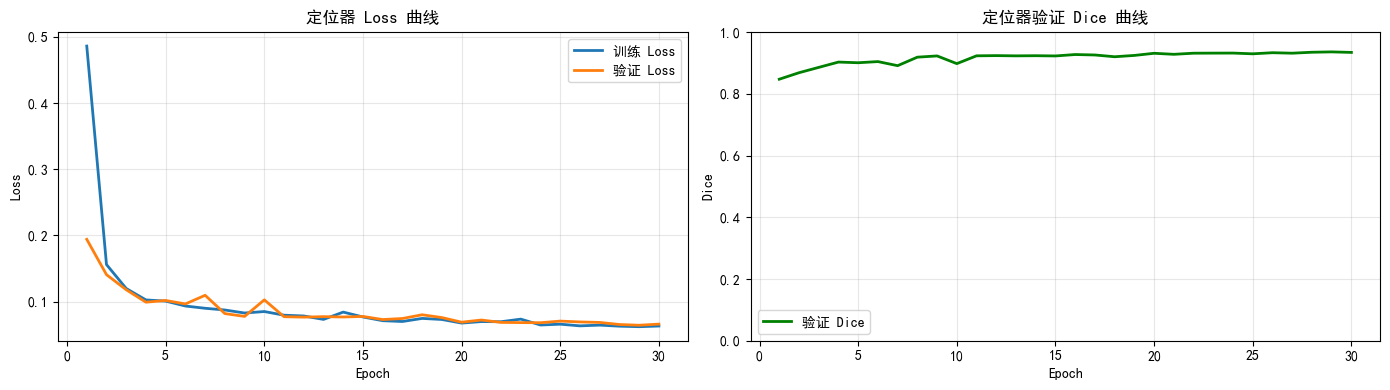

## 2. Baseline 训练曲线

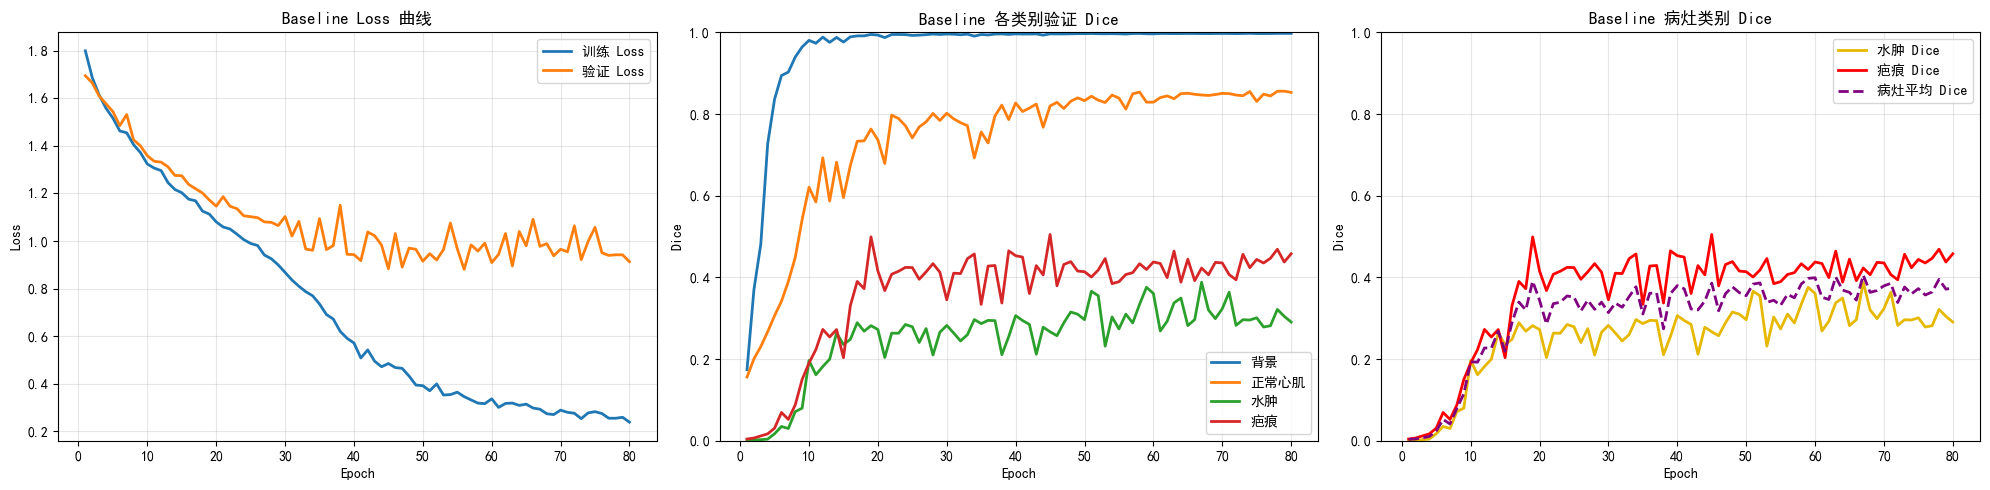

## 3. Cascade 训练曲线

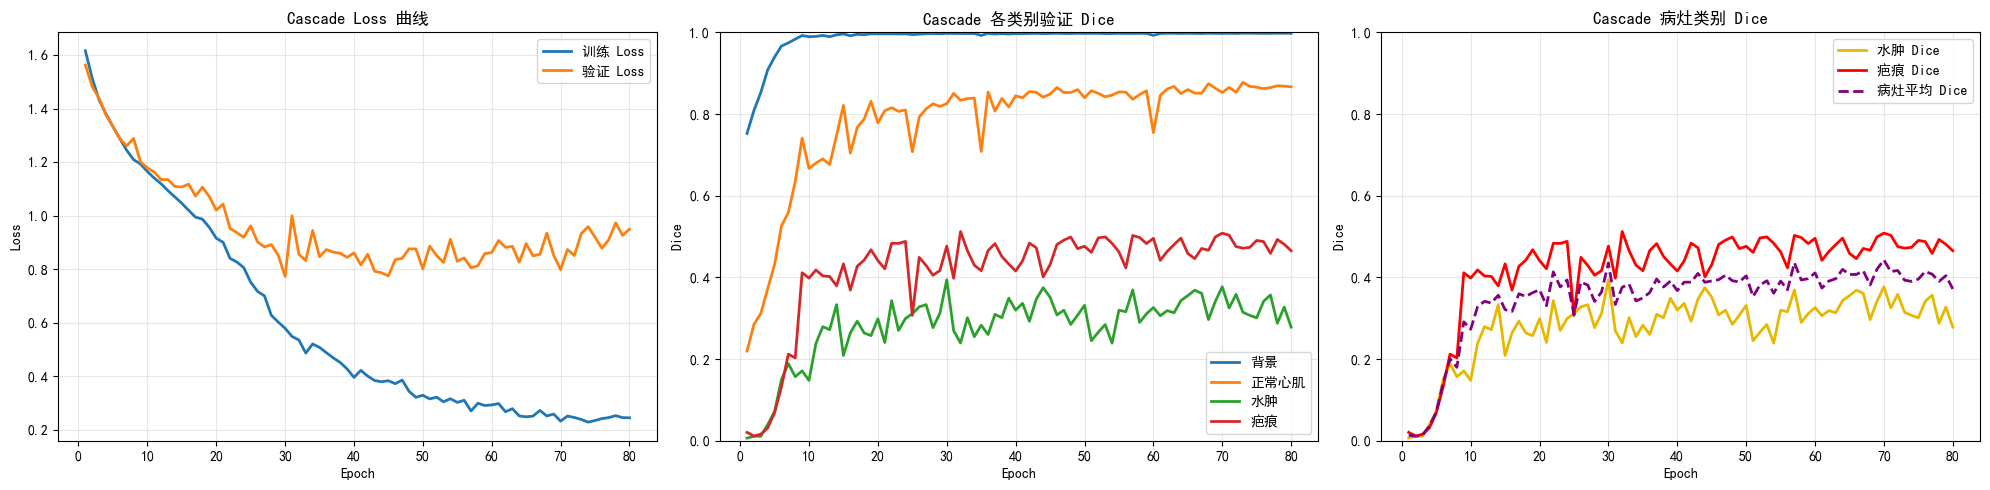

## 4. 测试集 Dice / HD95 指标对比

## 测试集评估结果表

,模型,类别,Dice均值,Dice标准差,HD95均值,HD95标准差
0,Baseline,背景,0.996167,0.002534,2.506598,1.450088
1,Baseline,正常心肌,0.861911,0.099886,7.750765,7.515043
2,Baseline,水肿,0.386865,0.297486,10.889006,9.404875
3,Baseline,疤痕,0.522153,0.298300,11.303744,9.182187
4,Cascade,背景,0.996882,0.001754,2.154791,1.011150
5,Cascade,正常心肌,0.866434,0.100718,7.465007,4.794944
6,Cascade,水肿,0.403437,0.304611,12.234368,9.495585
7,Cascade,疤痕,0.566164,0.305650,11.574413,11.338092


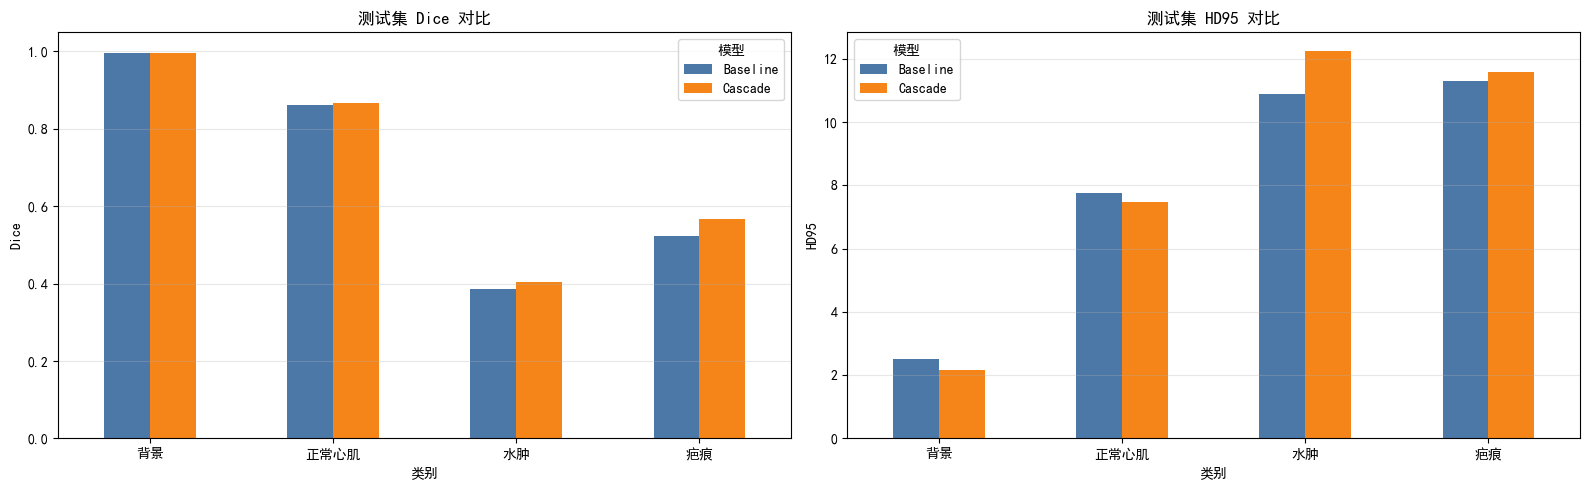

## 病灶类别 Dice 对比

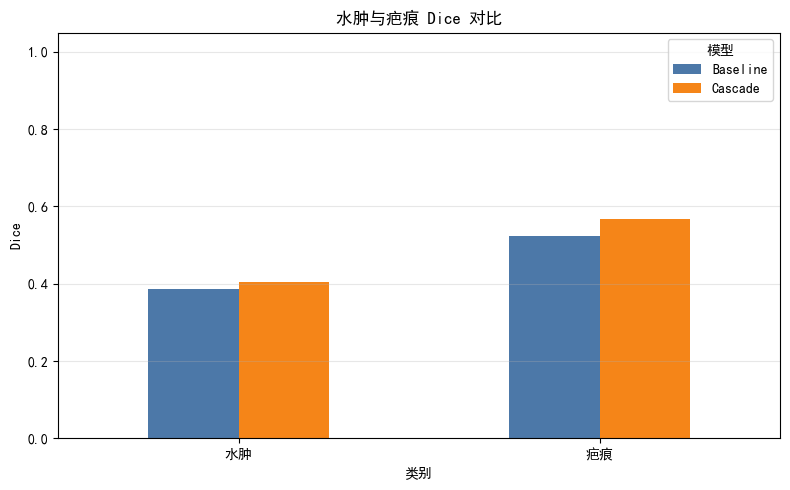

## Cascade 相对 Baseline 的 Dice 变化

,类别,Cascade - Baseline Dice变化
0,背景,0.000715
1,正常心肌,0.004523
2,水肿,0.016572
3,疤痕,0.044011


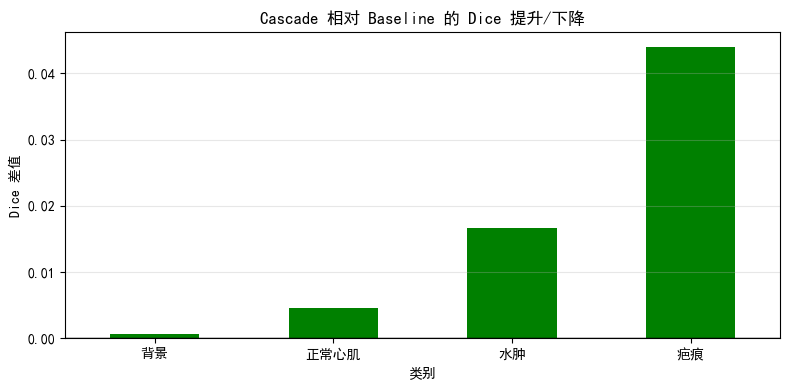

In [3]:
#可视化与结果分析
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

PROJECT_ROOT = Path(r"D:\a")
CURVE_DIR = PROJECT_ROOT / "results" / "curves"
TABLE_DIR = PROJECT_ROOT / "results" / "tables"

plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False


def read_csv_if_exists(path):
    if path.exists():
        return pd.read_csv(path)
    print(f"未找到文件：{path}")
    return None


def plot_locator_curves():
    path = CURVE_DIR / "locator_history.csv"
    df = read_csv_if_exists(path)
    if df is None:
        display(Markdown("### 定位器训练曲线\n未找到 `locator_history.csv`。如果模型是在加入训练历史记录之前训练的，需要重新训练后才会生成。"))
        return

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(df["epoch"], df["train_loss"], label="训练 Loss", linewidth=2)
    axes[0].plot(df["epoch"], df["val_loss"], label="验证 Loss", linewidth=2)
    axes[0].set_title("定位器 Loss 曲线")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].plot(df["epoch"], df["val_dice"], label="验证 Dice", color="green", linewidth=2)
    axes[1].set_title("定位器验证 Dice 曲线")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Dice")
    axes[1].set_ylim(0, 1)
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def plot_segmentor_curves(model_name, csv_name):
    path = CURVE_DIR / csv_name
    df = read_csv_if_exists(path)
    if df is None:
        display(Markdown(f"### {model_name} 训练曲线\n未找到 `{csv_name}`。如果模型是在加入训练历史记录之前训练的，需要重新训练后才会生成。"))
        return

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    axes[0].plot(df["epoch"], df["train_loss"], label="训练 Loss", linewidth=2)
    axes[0].plot(df["epoch"], df["val_loss"], label="验证 Loss", linewidth=2)
    axes[0].set_title(f"{model_name} Loss 曲线")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].plot(df["epoch"], df["val_dice_bg"], label="背景", linewidth=2)
    axes[1].plot(df["epoch"], df["val_dice_myo"], label="正常心肌", linewidth=2)
    axes[1].plot(df["epoch"], df["val_dice_edema"], label="水肿", linewidth=2)
    axes[1].plot(df["epoch"], df["val_dice_scar"], label="疤痕", linewidth=2)
    axes[1].set_title(f"{model_name} 各类别验证 Dice")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Dice")
    axes[1].set_ylim(0, 1)
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    axes[2].plot(df["epoch"], df["val_dice_edema"], label="水肿 Dice", color="#E6B800", linewidth=2)
    axes[2].plot(df["epoch"], df["val_dice_scar"], label="疤痕 Dice", color="red", linewidth=2)
    axes[2].plot(df["epoch"], df["val_dice_lesion_mean"], label="病灶平均 Dice", color="purple", linewidth=2, linestyle="--")
    axes[2].set_title(f"{model_name} 病灶类别 Dice")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Dice")
    axes[2].set_ylim(0, 1)
    axes[2].grid(alpha=0.3)
    axes[2].legend()

    plt.tight_layout()
    plt.show()


def plot_metrics_comparison():
    path = TABLE_DIR / "metrics_comparison.csv"
    df = read_csv_if_exists(path)
    if df is None:
        display(Markdown("### 测试集指标对比\n未找到 `metrics_comparison.csv`，请先运行 `evaluate.py` 或 `main.py`。"))
        return

    display(Markdown("## 测试集评估结果表"))
    display(df)

    class_order = ["背景", "正常心肌", "水肿", "疤痕"]

    dice_pivot = df.pivot(index="类别", columns="模型", values="Dice均值").reindex(class_order)
    hd95_pivot = df.pivot(index="类别", columns="模型", values="HD95均值").reindex(class_order)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    dice_pivot.plot(kind="bar", ax=axes[0], color=["#4C78A8", "#F58518"])
    axes[0].set_title("测试集 Dice 对比")
    axes[0].set_xlabel("类别")
    axes[0].set_ylabel("Dice")
    axes[0].set_ylim(0, 1.05)
    axes[0].grid(axis="y", alpha=0.3)
    axes[0].tick_params(axis="x", rotation=0)

    hd95_pivot.plot(kind="bar", ax=axes[1], color=["#4C78A8", "#F58518"])
    axes[1].set_title("测试集 HD95 对比")
    axes[1].set_xlabel("类别")
    axes[1].set_ylabel("HD95")
    axes[1].grid(axis="y", alpha=0.3)
    axes[1].tick_params(axis="x", rotation=0)

    plt.tight_layout()
    plt.show()

    display(Markdown("## 病灶类别 Dice 对比"))

    lesion_dice = dice_pivot.loc[["水肿", "疤痕"]]

    ax = lesion_dice.plot(kind="bar", figsize=(8, 5), color=["#4C78A8", "#F58518"])
    ax.set_title("水肿与疤痕 Dice 对比")
    ax.set_xlabel("类别")
    ax.set_ylabel("Dice")
    ax.set_ylim(0, 1.05)
    ax.grid(axis="y", alpha=0.3)
    ax.tick_params(axis="x", rotation=0)
    plt.tight_layout()
    plt.show()

    if "Baseline" in dice_pivot.columns and "Cascade" in dice_pivot.columns:
        improvement = dice_pivot["Cascade"] - dice_pivot["Baseline"]
        improvement_df = improvement.reset_index()
        improvement_df.columns = ["类别", "Cascade - Baseline Dice变化"]

        display(Markdown("## Cascade 相对 Baseline 的 Dice 变化"))
        display(improvement_df)

        colors = ["green" if v >= 0 else "red" for v in improvement.values]

        ax = improvement.plot(kind="bar", figsize=(8, 4), color=colors)
        ax.axhline(0, color="black", linewidth=1)
        ax.set_title("Cascade 相对 Baseline 的 Dice 提升/下降")
        ax.set_xlabel("类别")
        ax.set_ylabel("Dice 差值")
        ax.grid(axis="y", alpha=0.3)
        ax.tick_params(axis="x", rotation=0)
        plt.tight_layout()
        plt.show()


def plot_saved_images():
    image_paths = [
        CURVE_DIR / "dice_comparison_bar.png",
        CURVE_DIR / "hd95_comparison_bar.png",
        CURVE_DIR / "summary_dashboard.png",
        CURVE_DIR / "locator_training_curves.png",
        CURVE_DIR / "baseline_training_curves.png",
        CURVE_DIR / "cascade_training_curves.png",
    ]

    existing = [p for p in image_paths if p.exists()]
    if not existing:
        display(Markdown("### 已保存图片\n当前没有找到已保存的曲线图片。"))
        return

    display(Markdown("## 已保存的可视化图片"))

    for path in existing:
        img = plt.imread(path)
        plt.figure(figsize=(12, 6))
        plt.imshow(img)
        plt.title(path.name)
        plt.axis("off")
        plt.show()


display(Markdown("# 医学图像分割项目训练曲线与结果可视化"))

display(Markdown("## 1. 定位器训练曲线"))
plot_locator_curves()

display(Markdown("## 2. Baseline 训练曲线"))
plot_segmentor_curves("Baseline", "baseline_history.csv")

display(Markdown("## 3. Cascade 训练曲线"))
plot_segmentor_curves("Cascade", "cascade_history.csv")

display(Markdown("## 4. 测试集 Dice / HD95 指标对比"))
plot_metrics_comparison()

#display(Markdown("## 5. 已保存图像展示"))
#plot_saved_images()

## 9. 展示分割结果

### 分割结果可视化

每张图从左到右依次为：原始 bSSFP 图像、真实标签、Baseline 预测结果、Cascade 预测结果。

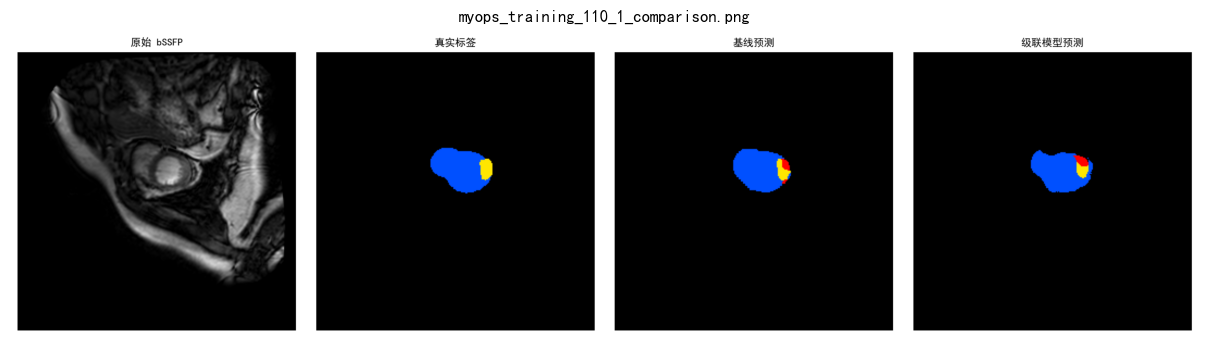

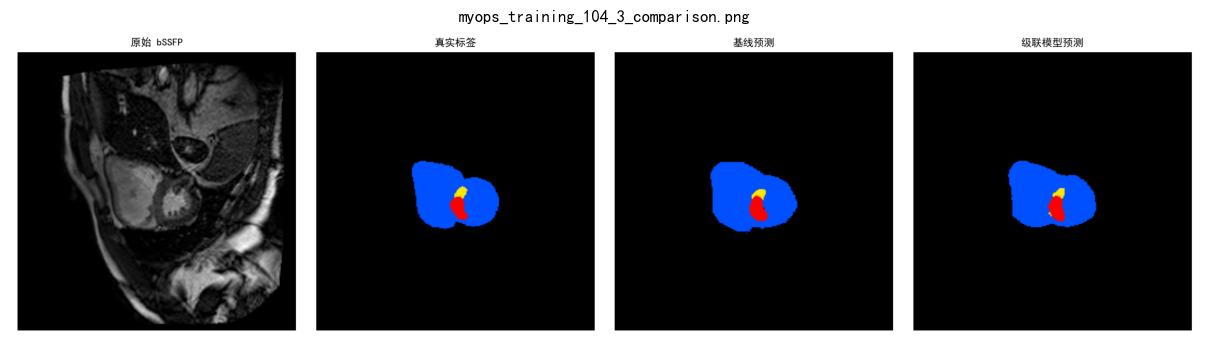

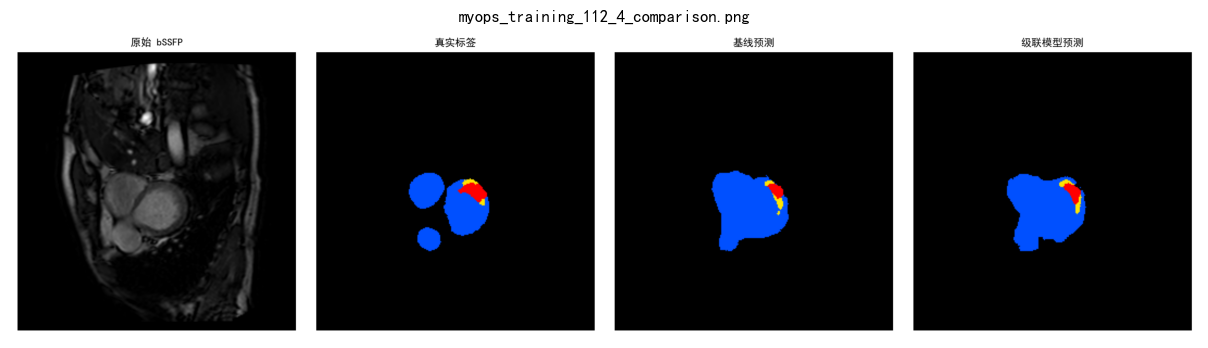

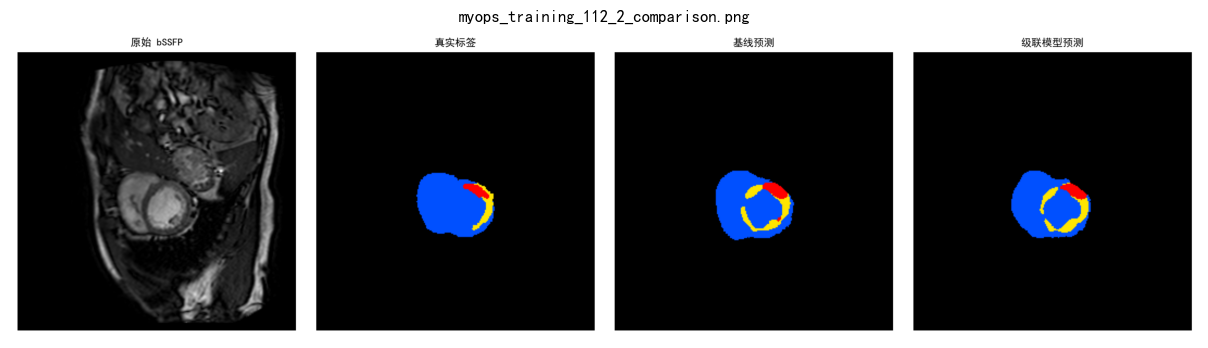

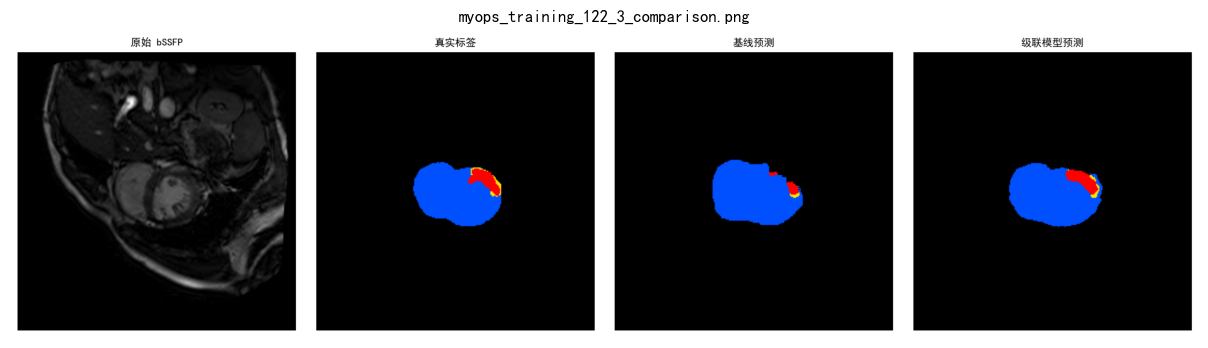

In [4]:
from pathlib import Path
import random
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, Markdown
PROJECT_ROOT = Path(r"D:\a")
FIGURE_DIR = PROJECT_ROOT / "results" / "figures"
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
def show_segmentation_results(num_cases=5, random_select=True):
    image_paths = sorted(FIGURE_DIR.glob("*_comparison.png"))
    if len(image_paths) == 0:
        display(Markdown(f"未找到分割结果图像：`{FIGURE_DIR}`。请先运行 `inference.py` 或 `main.py`。"))
        return
    if random_select:
        image_paths = random.sample(image_paths, min(num_cases, len(image_paths)))
    else:
        image_paths = image_paths[:num_cases]
    for path in image_paths:
        img = Image.open(path)
        plt.figure(figsize=(16, 4))
        plt.imshow(img)
        plt.title(path.name)
        plt.axis("off")
        plt.show()
display(Markdown("### 分割结果可视化"))
display(Markdown(
    "每张图从左到右依次为：原始 bSSFP 图像、真实标签、Baseline 预测结果、Cascade 预测结果。"
))
show_segmentation_results(num_cases=5, random_select=True)

## 10. 展示定位 Mask

### 定位器 Mask 叠加图

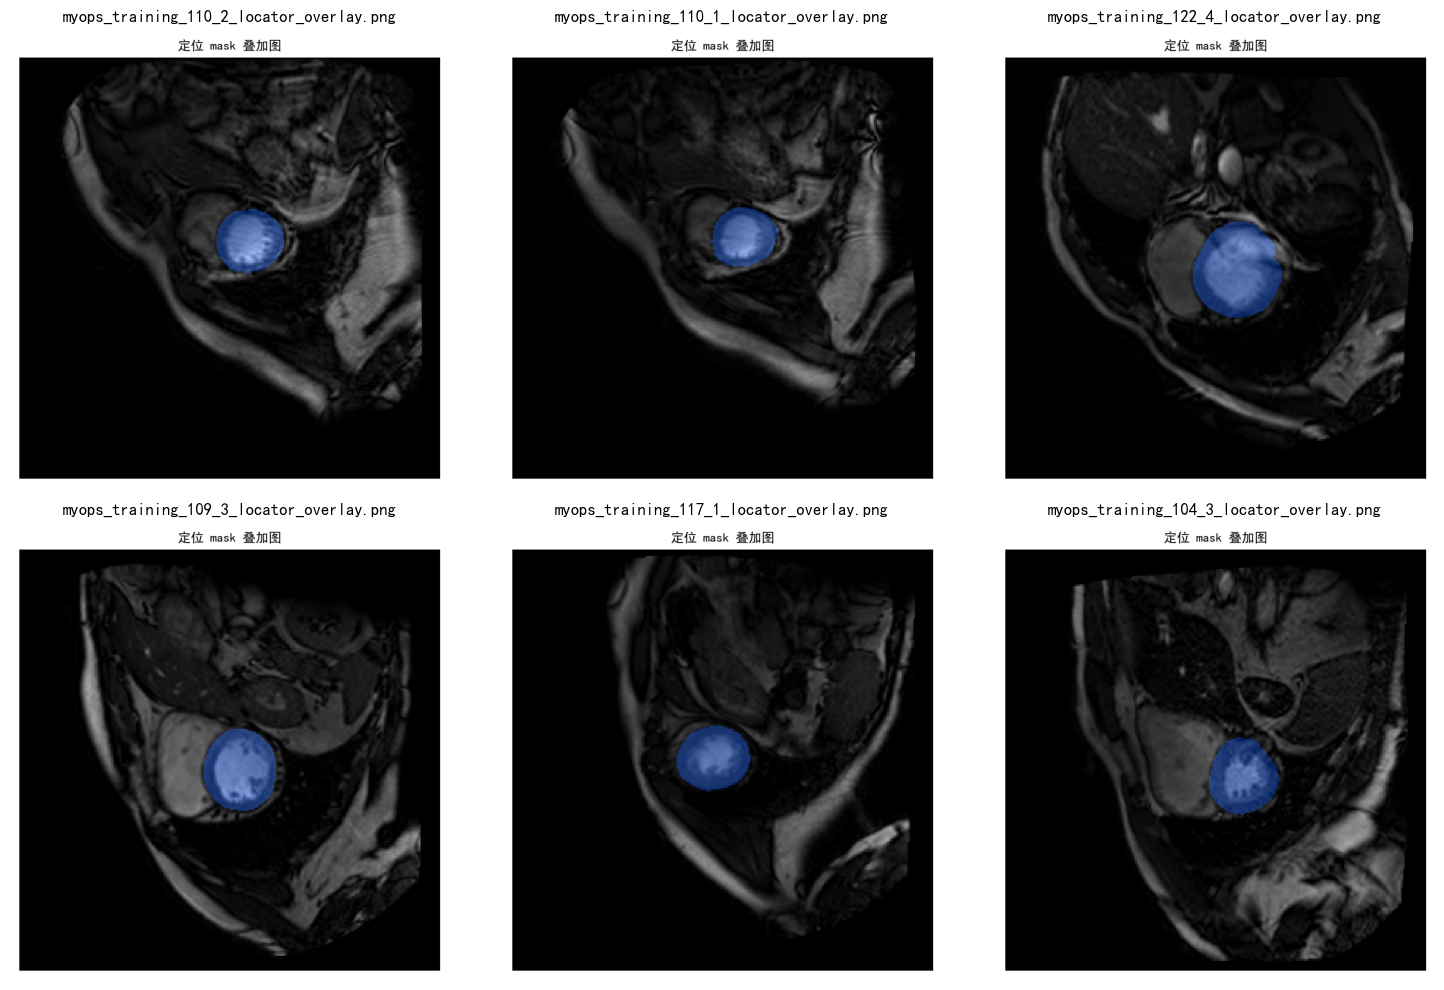

In [5]:
from pathlib import Path
import random
import math
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, Markdown
PROJECT_ROOT = Path(r"D:\a")
FIGURE_DIR = PROJECT_ROOT / "results" / "figures"
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
def show_locator_overlays(num_cases=6, random_select=True):
    image_paths = sorted(FIGURE_DIR.glob("*_locator_overlay.png"))
    if len(image_paths) == 0:
        display(Markdown(f"未找到定位 mask 叠加图：`{FIGURE_DIR}`。请先运行 `inference.py` 或 `main.py`。"))
        return
    if random_select:
        image_paths = random.sample(image_paths, min(num_cases, len(image_paths)))
    else:
        image_paths = image_paths[:num_cases]
    cols = min(3, len(image_paths))
    rows = math.ceil(len(image_paths) / cols)
    plt.figure(figsize=(5 * cols, 5 * rows))
    for i, path in enumerate(image_paths, start=1):
        img = Image.open(path)
        plt.subplot(rows, cols, i)
        plt.imshow(img)
        plt.title(path.name)
        plt.axis("off")
    plt.tight_layout()
    plt.show()
display(Markdown("### 定位器 Mask 叠加图"))
show_locator_overlays(num_cases=6, random_select=True)

## 七、项目总结

本项目围绕心脏医学图像分割任务，构建并实现了一种两阶段级联分割方法。整体思路是先利用 ACDC 数据集训练一个心肌区域定位器，获得心脏解剖结构的粗定位先验；再将该定位 mask 与 MyoPS 2020 数据集中的 LGE、T2、bSSFP 三模态图像进行融合，输入精细分割网络，完成背景、正常心肌、水肿和疤痕的四分类分割。

项目中同时实现了一个三通道标准 U-Net 作为 Baseline，用于与加入定位先验的 Cascade 模型进行对比。实验结果表明，经过 Dice 与交叉熵混合损失、类别权重调整和病灶切片加权采样等改进后，模型对水肿和疤痕等小目标类别的识别能力相比初始版本有明显提升。其中，Cascade 模型在疤痕 Dice 上优于 Baseline，说明解剖定位先验对部分病灶区域具有积极作用。

不过，实验也显示定位先验并非对所有类别都能带来一致提升。Baseline 在水肿分割和部分 HD95 指标上表现更好，说明水肿区域由于边界模糊、形态变化大，仍然是较难分割的类别。后续可以进一步优化定位 mask 的融合方式，例如将其作为软注意力提示，而不是直接作为强先验输入，同时结合边界损失或更精细的采样策略，进一步提升病灶区域的边界质量和整体分割稳定性。

总体来看，本项目完整实现了从数据加载、模型训练、级联推理、指标评估到可视化展示的医学图像分割流程，验证了引入解剖先验进行级联分割的可行性，也为后续改进多模态心肌病灶分割模型提供了实验基础。